In [39]:
import pandas as pd
import numpy as np
from credit_risk.utils.config import create_path,read_config
from statsmodels.stats.proportion import proportion_confint
from pathlib import Path

In [40]:
from pathlib import Path
import os

if "project_path" not in globals():
    project_path = Path.cwd().parent
    os.chdir(project_path)

print("Project path:", project_path)

Project path: c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk


In [41]:
config = read_config(Path("C:/Users/vorad/OneDrive/Desktop/Projects/mortgage-credit-risk"))

In [75]:
vintages = [2015, 2016, 2017, 2018, 2019]

dfs = []

for vintage in vintages:
    path = create_path(
        config["catalog"]["base"],
        config["catalog"],
        "model_input_path",
        "freddie_mac",
        vintage,
    )
    df_o = pd.read_parquet(path)
    df_o['vintage'] = vintage
    dfs.append(df_o)

df_o = pd.concat(dfs, ignore_index=True)

In [43]:
df.columns.values

<ArrowStringArray>
[                  'loan_id',              'credit_score',
              'original_dti',       'number_of_borrowers',
 'first_time_homebuyer_flag',              'original_ltv',
             'original_cltv',             'mi_percentage',
             'property_type',          'occupancy_status',
              'original_upb',    'original_interest_rate',
        'original_loan_term',              'loan_purpose',
                   'channel',     'super_conforming_flag',
            'harp_indicator',            'property_state',
      'original_dti_missing',            'ever_90dpd_24m',
                   'vintage']
Length: 21, dtype: str

In [44]:
df["vintage"].value_counts().sort_index()

vintage
2015    47255
2016    48046
2017    48242
2018    47394
2019    48555
Name: count, dtype: int64

In [45]:
df["ever_90dpd_24m"].value_counts(dropna=False)

ever_90dpd_24m
0    234696
1      4796
Name: count, dtype: int64

In [46]:
vintage_event_rate = (
    df.groupby("vintage")["ever_90dpd_24m"]
    .agg(
        population="count",
        events="sum",
        event_rate="mean",
    )
    .reset_index()
)

vintage_event_rate

,vintage,population,events,event_rate
0,2015,47255,343,0.007258
1,2016,48046,401,0.008346
2,2017,48242,509,0.010551
3,2018,47394,1287,0.027155
4,2019,48555,2256,0.046463


In [47]:
confidence_intervals = vintage_event_rate.apply(
    lambda row: proportion_confint(
        count=row["events"],
        nobs=row["population"],
        alpha=0.05,
        method="wilson",
    ),
    axis=1,
)

vintage_event_rate[["ci_lower", "ci_upper"]] = pd.DataFrame(
    confidence_intervals.tolist(),
    index=vintage_event_rate.index,
)

vintage_event_rate

,vintage,population,events,event_rate,ci_lower,ci_upper
0,2015,47255,343,0.007258,0.006532,0.008065
1,2016,48046,401,0.008346,0.007571,0.009200
2,2017,48242,509,0.010551,0.009677,0.011502
3,2018,47394,1287,0.027155,0.025730,0.028657
4,2019,48555,2256,0.046463,0.044626,0.048371


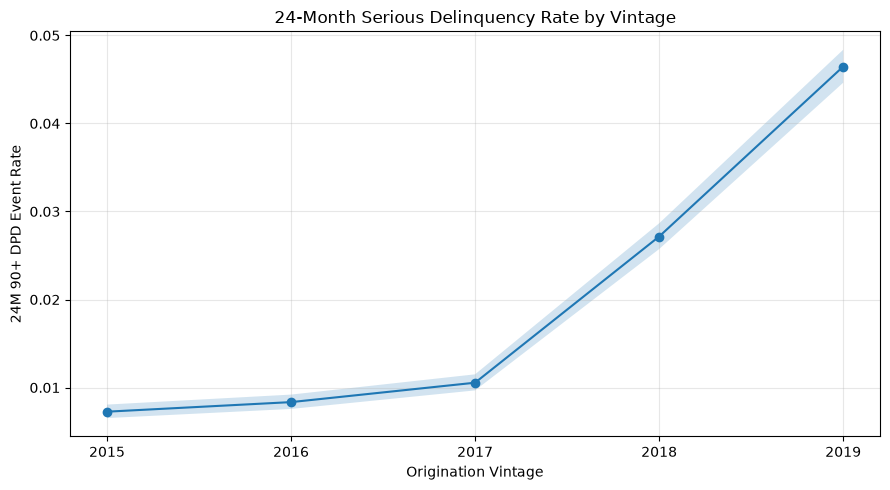

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    vintage_event_rate["vintage"],
    vintage_event_rate["event_rate"],
    marker="o",
)

ax.fill_between(
    vintage_event_rate["vintage"],
    vintage_event_rate["ci_lower"],
    vintage_event_rate["ci_upper"],
    alpha=0.2,
)

ax.set_xlabel("Origination Vintage")
ax.set_ylabel("24M 90+ DPD Event Rate")
ax.set_title("24-Month Serious Delinquency Rate by Vintage")

ax.set_xticks(vintage_event_rate["vintage"])

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
vintage_event_rate["yoy_change"] = vintage_event_rate["event_rate"].diff()

vintage_event_rate["yoy_pct_change"] = (
    vintage_event_rate["event_rate"].pct_change() * 100
)

vintage_event_rate

,vintage,population,events,event_rate,ci_lower,ci_upper,yoy_change,yoy_pct_change
0,2015,47255,343,0.007258,0.006532,0.008065,NaN,NaN
1,2016,48046,401,0.008346,0.007571,0.009200,0.001088,14.984892
2,2017,48242,509,0.010551,0.009677,0.011502,0.002205,26.416960
3,2018,47394,1287,0.027155,0.025730,0.028657,0.016604,157.372834
4,2019,48555,2256,0.046463,0.044626,0.048371,0.019307,71.099978


In [50]:
numeric_features = [
    "credit_score",
    "original_dti",
    "original_ltv",
    "original_cltv",
    "mi_percentage",
    "original_upb",
    "original_interest_rate",
    "original_loan_term",
]

vintage_numeric_summary = df.groupby("vintage")[numeric_features].agg(
    ["mean", "median"]
)

vintage_numeric_summary

credit_score        original_dti        original_ltv         \
                mean median         mean median         mean median   
vintage                                                               
2015      749.152661  759.0    33.887005   35.0     73.63874   78.0   
2016      748.713858  757.0    34.100754   35.0    73.264455   78.0   
2017      746.257037  752.0    35.157081   36.0    75.043157   80.0   
2018      747.766489  753.0     35.82897   37.0    75.934421   80.0   
2019      752.140809  757.0    35.309476   37.0    75.644136   80.0   

        original_cltv        mi_percentage          original_upb            \
                 mean median          mean median           mean    median   
vintage                                                                      
2015        74.546345   79.0      6.119289    0.0  221901.089832  199000.0   
2016        73.891708   79.0      6.239666    0.0  233480.955751  214000.0   
2017        75.501866   80.0      7.256416    0.0  229295.468679  207000.0   
2018        76.198447   80.0      8.267544    0.0  230181.077774  205000.0   
2019        75.812151   80.0      8.019874    0.0  253736.360828  232000.0   

        original_interest_rate        original_loan_term         
                          mean median               mean median  
vintage                                                          
2015                  3.974441    4.0         314.566586  360.0  
2016                  3.788878   3.75         317.109999  360.0  
2017                  4.190664    4.2         324.715642  360.0  
2018                  4.737915   4.75         333.336751  360.0  
2019                  4.234346  4.125         331.569601  360.0

In [51]:
import pandas as pd
categorical_features = [
    "number_of_borrowers",
    "first_time_homebuyer_flag",
    "property_type",
    "occupancy_status",
    "loan_purpose",
    "channel",
    "super_conforming_flag",
    "harp_indicator",
]

for col in categorical_features:
    print(f"\n--- {col} ---")

    print(
        pd.crosstab(
            df["vintage"],
            df[col],
            normalize="index",
        ).round(4)
    )


--- number_of_borrowers ---
number_of_borrowers       1       2       3       4    5
vintage                                                 
2015                 0.4905  0.5095  0.0000  0.0000  0.0
2016                 0.5061  0.4939  0.0000  0.0000  0.0
2017                 0.5246  0.4754  0.0000  0.0000  0.0
2018                 0.5414  0.4498  0.0075  0.0013  0.0
2019                 0.5387  0.4513  0.0090  0.0009  0.0

--- first_time_homebuyer_flag ---
first_time_homebuyer_flag       N       Y
vintage                                  
2015                       0.8455  0.1545
2016                       0.8393  0.1607
2017                       0.7851  0.2149
2018                       0.7335  0.2665
2019                       0.7748  0.2252

--- property_type ---
property_type      CO      CP      MH      PU      SF
vintage                                              
2015           0.0794  0.0013  0.0037  0.2613  0.6544
2016           0.0826  0.0014  0.0029  0.2678  0.6453
2017

In [52]:
loan_purpose_event_rate = (
    df.groupby(["vintage", "loan_purpose"])["ever_90dpd_24m"]
    .agg(
        population="count",
        events="sum",
        event_rate="mean",
    )
    .reset_index()
)

print(loan_purpose_event_rate)

    vintage loan_purpose  population  events  event_rate
0      2015            C        9823      59    0.006006
1      2015            N       16554     130    0.007853
2      2015            P       20878     154    0.007376
3      2016            C       10770      93    0.008635
4      2016            N       16080     116    0.007214
5      2016            P       21196     192    0.009058
6      2017            C       10911     115    0.010540
7      2017            N        9707      94    0.009684
8      2017            P       27624     300    0.010860
9      2018            C        9856     284    0.028815
10     2018            N        5830     144    0.024700
11     2018            P       31708     859    0.027091
12     2019            C       10252     508    0.049551
13     2019            N       11318     463    0.040908
14     2019            P       26985    1285    0.047619


In [53]:
df["credit_score_band"] = pd.cut(
    df["credit_score"],
    bins=[0, 650, 700, 750, 800, 850],
    labels=[
        "<650",
        "650-699",
        "700-749",
        "750-799",
        "800+",
    ],
    right=False,
)

In [54]:
credit_score_event_rate = (
    df.groupby(
        ["vintage", "credit_score_band"],
        observed=True,
    )["ever_90dpd_24m"]
    .agg(
        population="count",
        events="sum",
        event_rate="mean",
    )
    .reset_index()
)

print(credit_score_event_rate)

    vintage credit_score_band  population  events  event_rate
0      2015              <650        1518      60    0.039526
1      2015           650-699        6415     128    0.019953
2      2015           700-749       12551      90    0.007171
3      2015           750-799       20471      56    0.002736
4      2015              800+        6300       9    0.001429
5      2016              <650        1423      61    0.042867
6      2016           650-699        6565     151    0.023001
7      2016           700-749       13444     127    0.009447
8      2016           750-799       20362      54    0.002652
9      2016              800+        6252       8    0.001280
10     2017              <650        1713      89    0.051956
11     2017           650-699        7265     175    0.024088
12     2017           700-749       14300     165    0.011538
13     2017           750-799       19444      72    0.003703
14     2017              800+        5512       8    0.001451
15     2

In [55]:
credit_score_event_rate["yoy_pct_change"] = (
    credit_score_event_rate.groupby("credit_score_band")["event_rate"].pct_change()
    * 100
)

print(credit_score_event_rate)

    vintage credit_score_band  population  events  event_rate  yoy_pct_change
0      2015              <650        1518      60    0.039526             NaN
1      2015           650-699        6415     128    0.019953             NaN
2      2015           700-749       12551      90    0.007171             NaN
3      2015           750-799       20471      56    0.002736             NaN
4      2015              800+        6300       9    0.001429             NaN
5      2016              <650        1423      61    0.042867        8.453970
6      2016           650-699        6565     151    0.023001       15.273348
7      2016           700-749       13444     127    0.009447       31.737991
8      2016           750-799       20362      54    0.002652       -3.055236
9      2016              800+        6252       8    0.001280      -10.428663
10     2017              <650        1713      89    0.051956       21.201420
11     2017           650-699        7265     175    0.024088   

In [56]:
score_mix = (
    df[df["vintage"] == 2015]
    .groupby("credit_score_band")
    .size()
    .div(len(df[df["vintage"] == 2015]))
)

print(score_mix)

credit_score_band
<650       0.032124
650-699    0.135753
700-749    0.265602
750-799    0.433203
800+       0.133319
dtype: float64


In [57]:
standardized_event_rates = []

for vintage in sorted(df["vintage"].unique()):
    vintage_rates = credit_score_event_rate[
        credit_score_event_rate["vintage"] == vintage
    ].set_index("credit_score_band")["event_rate"]

    standardized_rate = (vintage_rates * score_mix).sum()

    standardized_event_rates.append(
        {
            "vintage": vintage,
            "standardized_event_rate": standardized_rate,
        }
    )

standardized_event_rates = pd.DataFrame(standardized_event_rates)

print(standardized_event_rates)

   vintage  standardized_event_rate
0     2015                 0.007258
1     2016                 0.008328
2     2017                 0.009801
3     2018                 0.026187
4     2019                 0.046670


In [58]:
df["ltv_band"] = pd.cut(
    df["original_ltv"],
    bins=[0, 60, 70, 80, 90, 100, np.inf],
    labels=[
        "<60",
        "60-69",
        "70-79",
        "80-89",
        "90-99",
        "100+",
    ],
    right=False,
)


ltv_event_rate = (
    df.groupby(
        ["vintage", "ltv_band"],
        observed=True,
    )["ever_90dpd_24m"]
    .agg(
        population="count",
        events="sum",
        event_rate="mean",
    )
    .reset_index()
)

print(ltv_event_rate)

    vintage ltv_band  population  events  event_rate
0      2015      <60        9004      34    0.003776
1      2015    60-69        5920      41    0.006926
2      2015    70-79        9946      55    0.005530
3      2015    80-89       12761      93    0.007288
4      2015    90-99        9123     101    0.011071
5      2015     100+         500      19    0.038000
6      2016      <60        9299      40    0.004302
7      2016    60-69        6206      42    0.006768
8      2016    70-79       10160      73    0.007185
9      2016    80-89       12690     111    0.008747
10     2016    90-99        9482     128    0.013499
11     2016     100+         209       7    0.033493
12     2017      <60        8176      44    0.005382
13     2017    60-69        5256      52    0.009893
14     2017    70-79        9269      69    0.007444
15     2017    80-89       13915     136    0.009774
16     2017    90-99       11510     200    0.017376
17     2017     100+         116       8    0.

In [64]:
performance_dfs = []

for vintage in range(2015, 2020):
    performance_path = create_path(
        config["catalog"]["base"],
        config["catalog"],
        "performance_path",
        "freddie_mac",
        vintage,
    )
    print(performance_path)
    df = pd.read_parquet(performance_path)
    df['vintage'] = vintage
    performance_dfs.append(df)

performance_df = pd.concat(
    performance_dfs,
    ignore_index=True,
)

data\02_intermediate\freddie_mac\2015\performance
data\02_intermediate\freddie_mac\2016\performance
data\02_intermediate\freddie_mac\2017\performance
data\02_intermediate\freddie_mac\2018\performance
data\02_intermediate\freddie_mac\2019\performance


In [65]:
performance_df["current_loan_delinquency_status"] = pd.to_numeric(
    performance_df["current_loan_delinquency_status"],
    errors="coerce",
)

first_90dpd = (
    performance_df[performance_df["current_loan_delinquency_status"] >= 3]
    .groupby("loan_id", as_index=False)
    .agg(
        first_90dpd_period=("period", "min"),
        first_90dpd_loan_age=("loan_age", "min"),
    )
)

In [66]:
first_90dpd.head()

,loan_id,first_90dpd_period,first_90dpd_loan_age
0,F15Q10002342,2020-06,64
1,F15Q10003844,2020-07,64
2,F15Q10004057,2017-07,30
3,F15Q10004454,2020-06,63
4,F15Q10004724,2020-09,67


In [67]:
first_90dpd.shape

(12825, 3)

In [70]:
events_24m = (
    performance_df[
        (performance_df["current_loan_delinquency_status"] >= 3)
        & (performance_df["loan_age"] <= 24)
    ]
    .groupby("loan_id", as_index=False)
    .agg(
        first_90dpd_period=("period", "min"),
        first_90dpd_loan_age=("loan_age", "min"),
        vintage=("vintage","min")
    )
)

In [71]:
events_24m.shape

(4915, 4)

In [72]:
events_24m["vintage"].value_counts().sort_index()

vintage
2015     345
2016     407
2017     515
2018    1333
2019    2315
Name: count, dtype: int64

In [73]:
target_events = df.loc[df["ever_90dpd_24m"] == 1, ["loan_id", "vintage"]].copy()

reconstructed_events = events_24m[["loan_id", "vintage"]].copy()

comparison = target_events.merge(
    reconstructed_events,
    on="loan_id",
    how="outer",
    suffixes=("_target", "_reconstructed"),
    indicator=True,
)

comparison["_merge"].value_counts()

KeyError: 'ever_90dpd_24m'

In [76]:
df_o.columns.values

<ArrowStringArray>
[                  'loan_id',              'credit_score',
              'original_dti',       'number_of_borrowers',
 'first_time_homebuyer_flag',              'original_ltv',
             'original_cltv',             'mi_percentage',
             'property_type',          'occupancy_status',
              'original_upb',    'original_interest_rate',
        'original_loan_term',              'loan_purpose',
                   'channel',     'super_conforming_flag',
            'harp_indicator',            'property_state',
      'original_dti_missing',            'ever_90dpd_24m',
                   'vintage']
Length: 21, dtype: str

In [77]:
target_events = df_o.loc[df_o["ever_90dpd_24m"] == 1, ["loan_id", "vintage"]].copy()

reconstructed_events = events_24m[["loan_id", "vintage"]].copy()

comparison = target_events.merge(
    reconstructed_events,
    on="loan_id",
    how="outer",
    suffixes=("_target", "_reconstructed"),
    indicator=True,
)

comparison["_merge"].value_counts()

_merge
both          4795
right_only     120
left_only        1
Name: count, dtype: int64

In [79]:
extra_events = comparison.loc[comparison["_merge"] == "right_only", ["loan_id"]].copy()

extra_history = performance_df[
    performance_df["loan_id"].isin(extra_events["loan_id"])
].copy()

extra_history[
    [
        "loan_id",
        "period",
        "loan_age",
        "current_loan_delinquency_status",
        "zero_balance_code",
        "zero_balance_effective_date",
        "delinquency_due_to_disaster",
    ]
].sort_values(["loan_id", "period"])

,loan_id,period,loan_age,current_loan_delinquency_status,zero_balance_code,zero_balance_effective_date,delinquency_due_to_disaster
879536,F15Q10354263,2015-06,2,0,<NA>,NaT,<NA>
879537,F15Q10354263,2015-07,3,0,<NA>,NaT,<NA>
879538,F15Q10354263,2015-08,4,0,<NA>,NaT,<NA>
879539,F15Q10354263,2015-09,5,0,<NA>,NaT,<NA>
879540,F15Q10354263,2015-10,6,0,<NA>,NaT,<NA>
...,...,...,...,...,...,...,...
13638325,F19Q40544370,2021-04,15,0,<NA>,NaT,<NA>
13638326,F19Q40544370,2021-05,16,0,<NA>,NaT,<NA>
13638327,F19Q40544370,2021-06,17,0,<NA>,NaT,<NA>
13638328,F19Q40544370,2021-07,18,0,<NA>,NaT,<NA>


In [80]:
extra_summary = (
    extra_history[extra_history["current_loan_delinquency_status"] >= 3]
    .groupby("loan_id", as_index=False)
    .agg(
        first_90dpd_period=("period", "min"),
        first_90dpd_age=("loan_age", "min"),
        zero_balance_code=("zero_balance_code", "first"),
        zero_balance_date=("zero_balance_effective_date", "first"),
        disaster_flag=("delinquency_due_to_disaster", "max"),
    )
)

extra_summary.head(20)

,loan_id,first_90dpd_period,first_90dpd_age,zero_balance_code,zero_balance_date,disaster_flag
0,F15Q10354263,2016-11,19,16,2020-09,<NA>
1,F15Q40312731,2017-02,15,03,2018-01,<NA>
2,F15Q40320787,2018-01,24,<NA>,NaT,Y
3,F16Q10238895,2016-11,9,02,2018-05,<NA>
4,F16Q10296408,2018-10,16,<NA>,NaT,Y
5,F16Q20365498,2017-12,19,<NA>,NaT,Y
6,F16Q30476472,2018-09,23,01,2018-09,<NA>
7,F16Q40355986,2017-11,12,<NA>,NaT,Y
8,F16Q40466206,2018-09,20,01,2018-09,<NA>
9,F17Q20324438,2017-11,5,<NA>,NaT,Y


In [81]:
extra_summary["disaster_flag"] = extra_summary["disaster_flag"].fillna("N")

extra_summary["zero_balance_code"] = (
    extra_summary["zero_balance_code"].fillna("NONE").astype(str)
)

extra_summary.groupby(["disaster_flag", "zero_balance_code"]).size().reset_index(
    name="count"
)

,disaster_flag,zero_balance_code,count
0,N,01,2
1,N,02,1
2,N,03,1
3,N,16,1
4,N,NONE,13
5,Y,15,1
6,Y,NONE,101


In [82]:
extra_summary["first_90dpd_age"].value_counts().sort_index()

first_90dpd_age
5      2
6      4
7      8
8      3
9      4
10     7
11     2
12     7
13     6
14     5
15     5
16     8
17     7
18     7
19     7
20    12
21     2
22     7
23     8
24     9
Name: count, dtype: Int64

In [83]:
extra_summary.groupby(
    ["disaster_flag", "zero_balance_code"],
    dropna=False,
).size().reset_index(name="count")

,disaster_flag,zero_balance_code,count
0,N,01,2
1,N,02,1
2,N,03,1
3,N,16,1
4,N,NONE,13
5,Y,15,1
6,Y,NONE,101


In [84]:
extra_summary["disaster_flag"].value_counts(dropna=False)

disaster_flag
Y    102
N     18
Name: count, dtype: int64[pyarrow]

In [85]:
extra_summary["zero_balance_code"].value_counts(dropna=False)

zero_balance_code
NONE    114
01        2
16        1
03        1
02        1
15        1
Name: count, dtype: int64

In [86]:
non_disaster_extras = extra_summary[extra_summary["disaster_flag"] == "N"]

non_disaster_extras.shape

(18, 6)

In [87]:
non_disaster_extras[
    [
        "loan_id",
        "first_90dpd_period",
        "first_90dpd_age",
        "zero_balance_code",
        "zero_balance_date",
        "disaster_flag",
    ]
].sort_values("first_90dpd_period")

,loan_id,first_90dpd_period,first_90dpd_age,zero_balance_code,zero_balance_date,disaster_flag
0,F15Q10354263,2016-11,19,16,2020-09,N
3,F16Q10238895,2016-11,9,02,2018-05,N
1,F15Q40312731,2017-02,15,03,2018-01,N
13,F17Q30379501,2018-03,6,NONE,NaT,N
6,F16Q30476472,2018-09,23,01,2018-09,N
8,F16Q40466206,2018-09,20,01,2018-09,N
12,F17Q30377941,2018-12,15,NONE,NaT,N
15,F18Q10228948,2019-03,13,NONE,NaT,N
40,F18Q30332130,2019-04,8,NONE,NaT,N
17,F18Q10287763,2019-05,14,NONE,NaT,N


In [88]:
non_disaster_extras["zero_balance_code"].value_counts()

zero_balance_code
NONE    13
01       2
16       1
03       1
02       1
Name: count, dtype: int64

In [89]:
non_disaster_no_01 = non_disaster_extras[
    non_disaster_extras["zero_balance_code"] != "01"
].copy()

non_disaster_no_01[
    [
        "loan_id",
        "first_90dpd_period",
        "first_90dpd_age",
        "zero_balance_code",
        "zero_balance_date",
        "disaster_flag",
    ]
].sort_values("first_90dpd_period")

,loan_id,first_90dpd_period,first_90dpd_age,zero_balance_code,zero_balance_date,disaster_flag
0,F15Q10354263,2016-11,19,16,2020-09,N
3,F16Q10238895,2016-11,9,02,2018-05,N
1,F15Q40312731,2017-02,15,03,2018-01,N
13,F17Q30379501,2018-03,6,NONE,NaT,N
12,F17Q30377941,2018-12,15,NONE,NaT,N
15,F18Q10228948,2019-03,13,NONE,NaT,N
40,F18Q30332130,2019-04,8,NONE,NaT,N
17,F18Q10287763,2019-05,14,NONE,NaT,N
47,F18Q40254314,2019-05,6,NONE,NaT,N
59,F18Q40286445,2019-07,7,NONE,NaT,N


In [90]:
target_event_timing = events_24m[
    ["loan_id", "first_90dpd_period", "first_90dpd_loan_age"]
].merge(
    df_o[["loan_id", "vintage", "ever_90dpd_24m"]],
    on="loan_id",
    how="inner",
    validate="one_to_one",
)

target_event_timing = target_event_timing[
    target_event_timing["ever_90dpd_24m"] == 1
].copy()

In [92]:
target_event_timing["event_year"] = target_event_timing["first_90dpd_period"].dt.year

In [95]:
event_timing = (
    target_event_timing.groupby(["vintage", "event_year"]).size().unstack(fill_value=0)
)

event_timing

event_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
vintage,,,,,,,,,,,,
2015,14,101,129,7,17,32,5,10,13,5,6,3
2016,0,9,195,121,1,23,12,13,14,8,2,3
2017,0,0,102,157,131,15,18,24,24,20,15,3
2018,0,0,0,13,171,1046,8,11,17,12,7,2
2019,0,0,0,0,34,1944,255,1,4,6,11,1


In [96]:
target_event_timing_24m = target_event_timing[
    target_event_timing["first_90dpd_loan_age"] <= 24
].copy()

In [97]:
target_event_timing_24m.groupby("vintage").size()

vintage
2015     342
2016     401
2017     509
2018    1287
2019    2256
dtype: int64

In [98]:
df_o.groupby("vintage")["ever_90dpd_24m"].sum()

vintage
2015     343
2016     401
2017     509
2018    1287
2019    2256
Name: ever_90dpd_24m, dtype: int64

In [100]:
target_event_timing_24m["event_year"] = target_event_timing_24m[
    "first_90dpd_period"
].dt.year

event_timing = (
    target_event_timing_24m.groupby(["vintage", "event_year"])
    .size()
    .unstack(fill_value=0)
)

event_timing

event_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
vintage,,,,,,,,,,,,
2015,14,101,129,7,17,32,5,10,13,5,6,3
2016,0,9,195,121,1,23,12,13,14,8,2,3
2017,0,0,102,157,131,15,18,24,24,20,15,3
2018,0,0,0,13,171,1046,8,11,17,12,7,2
2019,0,0,0,0,34,1944,255,1,4,6,11,1


In [101]:
target_event_timing_24m["event_year"] = target_event_timing_24m[
    "first_90dpd_period"
].dt.year

event_timing = (
    target_event_timing_24m.groupby(["vintage", "event_year"])
    .size()
    .unstack(fill_value=0)
)

event_timing

event_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
vintage,,,,,,,,,,,,
2015,14,101,129,7,17,32,5,10,13,5,6,3
2016,0,9,195,121,1,23,12,13,14,8,2,3
2017,0,0,102,157,131,15,18,24,24,20,15,3
2018,0,0,0,13,171,1046,8,11,17,12,7,2
2019,0,0,0,0,34,1944,255,1,4,6,11,1


In [102]:
target_event_timing_24m["first_90dpd_loan_age"].max()

np.int64(24)

In [103]:
target_event_timing_24m[target_event_timing_24m["event_year"] >= 2022][
    ["vintage", "event_year", "first_90dpd_loan_age"]
].sort_values("event_year")

,vintage,event_year,first_90dpd_loan_age
78,2015,2022,16
96,2015,2022,3
71,2015,2022,5
222,2015,2022,7
178,2015,2022,3
...,...,...,...
429,2016,2026,9
630,2016,2026,11
1356,2018,2026,16
1308,2018,2026,9


In [104]:
loan_id = target_event_timing_24m.loc[
    (target_event_timing_24m["vintage"] == 2015)
    & (target_event_timing_24m["event_year"] == 2022),
    "loan_id",
].iloc[0]

loan_id

'F15Q20019305'

In [105]:
performance_df[performance_df["loan_id"] == loan_id][
    [
        "loan_id",
        "period",
        "loan_age",
        "current_loan_delinquency_status",
    ]
].sort_values("period")

,loan_id,period,loan_age,current_loan_delinquency_status
939499,F15Q20019305,2015-05,0,0
939500,F15Q20019305,2015-06,1,0
939501,F15Q20019305,2015-07,2,0
939502,F15Q20019305,2015-08,3,0
939503,F15Q20019305,2015-09,4,0
...,...,...,...,...
939625,F15Q20019305,2025-11,41,1
939626,F15Q20019305,2025-12,42,0
939627,F15Q20019305,2026-01,43,0
939628,F15Q20019305,2026-02,44,0


In [106]:
df_o[df_o["loan_id"] == loan_id][
    [
        "loan_id",
        "vintage",
        "ever_90dpd_24m",
    ]
]

,loan_id,vintage,ever_90dpd_24m
12340,F15Q20019305,2015,1


In [113]:
events_24m_clean = (
    performance_df[
        performance_df["loan_age"].between(0, 24)
        & (performance_df["current_loan_delinquency_status"] >= 3)
    ]
    .sort_values(["loan_id", "loan_age"])
    .groupby("loan_id", as_index=False)
    .head(1)
)

In [114]:
events_24m_clean = events_24m_clean[["loan_id", "period", "loan_age"]].rename(
    columns={
        "period": "first_90dpd_period",
        "loan_age": "first_90dpd_loan_age",
    }
)

In [115]:
events_24m_clean = events_24m_clean.merge(
    df_o[["loan_id", "vintage", "ever_90dpd_24m"]],
    on="loan_id",
    how="inner",
    validate="one_to_one",
)

In [116]:
events_24m_clean.groupby("vintage").size()

vintage
2015     342
2016     401
2017     509
2018    1287
2019    2256
dtype: int64

In [117]:
df_o.groupby("vintage")["ever_90dpd_24m"].sum()

vintage
2015     343
2016     401
2017     509
2018    1287
2019    2256
Name: ever_90dpd_24m, dtype: int64

In [118]:
events_24m_clean["event_year"] = events_24m_clean["first_90dpd_period"].dt.year

events_24m_clean.groupby(["vintage", "event_year"]).size().unstack(fill_value=0)

event_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
vintage,,,,,,,,,,,,
2015,14,88,117,17,20,39,5,13,14,5,7,3
2016,0,8,180,115,11,30,14,13,14,10,3,3
2017,0,0,99,146,108,35,22,26,25,20,21,7
2018,0,0,0,13,139,1019,20,29,26,15,19,7
2019,0,0,0,0,34,1905,247,20,14,14,20,2


In [119]:
events_24m_clean[
    (events_24m_clean["vintage"] == 2015) & (events_24m_clean["event_year"] == 2026)
][
    [
        "loan_id",
        "vintage",
        "first_90dpd_period",
        "first_90dpd_loan_age",
    ]
]

,loan_id,vintage,first_90dpd_period,first_90dpd_loan_age
25,F15Q10102742,2015,2026-02,8
60,F15Q10311965,2015,2026-03,18
67,F15Q10363877,2015,2026-02,11


In [120]:
df_o[
    df_o["loan_id"].isin(
        events_24m_clean.loc[
            (events_24m_clean["vintage"] == 2015)
            & (events_24m_clean["event_year"] >= 2025),
            "loan_id",
        ]
    )
][["loan_id", "vintage"]]

,loan_id,vintage
2283,F15Q10069131,2015
3406,F15Q10102742,2015
10563,F15Q10311965,2015
11806,F15Q10363877,2015
12455,F15Q20023020,2015
13330,F15Q20050838,2015
13400,F15Q20053277,2015
16922,F15Q20167872,2015
23345,F15Q20388570,2015
46659,F15Q40302809,2015


In [122]:
loan_id = "F15Q10069131"
performance_df[performance_df["loan_id"] == loan_id][
    [
        "loan_id",
        "period",
        "loan_age",
        "current_loan_delinquency_status",
    ]
].sort_values("period")

,loan_id,period,loan_age,current_loan_delinquency_status
160454,F15Q10069131,2015-03,0,0
160455,F15Q10069131,2015-04,1,0
160456,F15Q10069131,2015-05,2,0
160457,F15Q10069131,2015-06,3,0
160458,F15Q10069131,2015-07,4,0
...,...,...,...,...
160582,F15Q10069131,2025-11,6,0
160583,F15Q10069131,2025-12,7,0
160584,F15Q10069131,2026-01,8,0
160585,F15Q10069131,2026-02,9,0


In [123]:
comparison = pd.DataFrame(
    {
        "vintage": [2015, 2016, 2017, 2018, 2019],
        "raw_event_rate": [
            0.007258491,
            0.008346168,
            0.010550972,
            0.027155336,
            0.046462774,
        ],
        "standardized_event_rate": [
            0.007258,
            0.008328,
            0.009801,
            0.026187,
            0.046670,
        ],
    }
)

comparison["mix_effect"] = (
    comparison["raw_event_rate"] - comparison["standardized_event_rate"]
)

comparison["mix_effect_pct"] = (
    comparison["mix_effect"] / comparison["raw_event_rate"] * 100
)

comparison

,vintage,raw_event_rate,standardized_event_rate,mix_effect,mix_effect_pct
0,2015,0.007258,0.007258,4.910000e-07,0.006764
1,2016,0.008346,0.008328,1.816800e-05,0.217681
2,2017,0.010551,0.009801,7.499720e-04,7.108084
3,2018,0.027155,0.026187,9.683360e-04,3.565914
4,2019,0.046463,0.046670,-2.072260e-04,-0.446004
